# Face Recognition Attendance System
### A complete end-to-end project — Python + OpenCV + Jupyter Notebook

This notebook builds a **real face recognition attendance system** that:

- Detects faces in real time using your webcam
- **Recognizes** registered people (not just "a face" — but *whose* face)
- Automatically logs **Entry Time**, **Exit Time**, **Date**, and **Total Hours**
- Prevents duplicate entries (won't mark you present 50 times in one session)
- Exports everything automatically to a **well-formatted Excel file**
- Has a simple daily **Dashboard** (attendance %, late arrivals, summary charts)
- Sends an optional **low-confidence alert** so strangers aren't marked present

---

## How it works (pipeline)

```
Step 1: Register people        →  capture ~60 face images per person (dataset/)
Step 2: Train recognizer       →  train an LBPH model on those faces (trainer/)
Step 3: Run attendance         →  webcam detects + recognizes faces live
Step 4: Auto-logging           →  first detection = Entry, last seen = Exit
Step 5: Export                 →  attendance auto-saved to Excel (.xlsx)
Step 6: Dashboard              →  view/analyze attendance stats
```

## Why LBPH instead of `face_recognition`/`dlib`?

`dlib` is powerful but is notoriously painful to install on Windows (needs CMake + C++ build tools)
and is slow to install in general. This project uses **OpenCV's built-in LBPH Face Recognizer**
(`opencv-contrib-python`), which:
- Installs in one `pip install` line, no compiler needed
- Runs fast enough for real-time webcam recognition
- Is accurate enough for attendance-style use cases (controlled, front-facing camera)

> If you *want* higher accuracy later, this notebook is structured so you can swap in
> `face_recognition` (dlib-based) with minimal changes — see the "Going Further" section at the end.

---

## Step 0: Install Requirements

Run this once. (In Jupyter, `!pip install` runs a shell command.)


In [1]:
# Install required packages
# opencv-contrib-python includes cv2.face (LBPH recognizer) - the plain opencv-python does NOT
!pip install opencv-contrib-python pandas openpyxl numpy pillow --quiet

print("All packages installed successfully!")

All packages installed successfully!



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Project Folder Setup

We create a clean folder structure:

```
attendance_system/
│
├── dataset/            <- captured face images go here (per person subfolder)
├── trainer/             <- trained recognition model + label map
├── attendance_records/  <- exported Excel attendance sheets (auto-created, one per month)
└── haarcascade_frontalface_default.xml   <- face detector (auto-downloaded)
```

Run the cell below to create everything and download the face detector file.


In [2]:
import os
import cv2
import urllib.request

# ---- Folder setup ----
# Notebook lives in: <project_root>/notebooks/this_file.ipynb
# We want all data folders at <project_root>/..., NOT inside notebooks/,
# so this works correctly no matter where Jupyter's working directory is.
NOTEBOOK_DIR = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))  # one level up from notebooks/

DATASET_DIR = os.path.join(BASE_DIR, "dataset")
TRAINER_DIR = os.path.join(BASE_DIR, "trainer")
RECORDS_DIR = os.path.join(BASE_DIR, "attendance_records")
CASCADE_PATH = os.path.join(BASE_DIR, "haarcascade_frontalface_default.xml")

for folder in [DATASET_DIR, TRAINER_DIR, RECORDS_DIR]:
    os.makedirs(folder, exist_ok=True)

# ---- Download Haar Cascade face detector if not already present ----
if not os.path.exists(CASCADE_PATH):
    print("Downloading face detector model...")
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, CASCADE_PATH)
    print("Downloaded haarcascade_frontalface_default.xml")
else:
    print("Face detector already present")

print("\nProject root detected as:", BASE_DIR)
print("Project structure ready:")
for folder in [DATASET_DIR, TRAINER_DIR, RECORDS_DIR]:
    print(" -", folder)

Downloaded haarcascade_frontalface_default.xml

Project root detected as: c:\Users\Ranjit Senapati\Desktop\CTTC AI ML INTERNSHIP\ALL PROJECTS\face-recognition-attendance-system\face-recognition-attendance-system
Project structure ready:
 - c:\Users\Ranjit Senapati\Desktop\CTTC AI ML INTERNSHIP\ALL PROJECTS\face-recognition-attendance-system\face-recognition-attendance-system\dataset
 - c:\Users\Ranjit Senapati\Desktop\CTTC AI ML INTERNSHIP\ALL PROJECTS\face-recognition-attendance-system\face-recognition-attendance-system\trainer
 - c:\Users\Ranjit Senapati\Desktop\CTTC AI ML INTERNSHIP\ALL PROJECTS\face-recognition-attendance-system\face-recognition-attendance-system\attendance_records


## Step 2: Configuration

Edit settings here (camera index, working hours, office start time for "late" marking, etc.)
This is the **only cell you should need to touch** to customize behavior.


In [3]:
# ================== CONFIGURATION ==================

CAMERA_INDEX = 0              # 0 = default webcam. Try 1 or 2 if you have multiple cameras.

IMAGES_PER_PERSON = 60        # how many face samples to capture per person during registration

RECOGNITION_CONFIDENCE_THRESHOLD = 65   # LBPH: LOWER value = more confident match.
                                          # Typical good range: 45-75. Increase if real people
                                          # are being rejected; decrease if strangers are accepted.

OFFICE_START_TIME = "09:30"    # 24hr format (9:30 AM) — used to flag "Late" arrivals
OFFICE_END_TIME   = "17:00"    # 24hr format (5:00 PM) — official close time, used to flag "Early Leave"

EXCEL_FILENAME_PATTERN = "Attendance_{month}_{year}.xlsx"   # one workbook per month, auto-created

print("Configuration loaded")
print(f"Camera index: {CAMERA_INDEX}")
print(f"Recognition threshold: {RECOGNITION_CONFIDENCE_THRESHOLD}")
print(f"Office hours: {OFFICE_START_TIME} - {OFFICE_END_TIME}")
print(f"Mode: explicit scan-in / scan-out (press i / o during the live session)")

Configuration loaded
Camera index: 0
Recognition threshold: 65
Office hours: 09:30 - 17:00
Mode: explicit scan-in / scan-out (press i / o during the live session)


## Step 3: Register People (Capture Face Dataset)

This step opens your webcam and captures multiple face images of a person to train the recognizer.

**Instructions while capturing:**
- Look at the camera, and slowly turn your head slightly (left/right/up/down) — this makes recognition much more robust
- Try with/without glasses if you sometimes wear them
- Good, even lighting = better accuracy
- Press **`q`** to stop early if needed

Run the cell, then enter the person's **ID number** (a unique integer, e.g. `1`, `2`, `3`) and **name** when prompted.

> Run this cell once **for every person** you want the system to recognize.


In [4]:
import cv2
import os

def register_new_face():
    face_detector = cv2.CascadeClassifier(CASCADE_PATH)

    person_id = input("Enter numeric ID for this person (e.g. 1, 2, 3): ").strip()
    person_name = input("Enter full name: ").strip()

    if not person_id.isdigit():
        print("ID must be a number. Try again.")
        return

    # Save mapping of ID -> Name in a small text file (label map)
    label_map_path = os.path.join(TRAINER_DIR, "label_map.txt")
    label_map = {}
    if os.path.exists(label_map_path):
        with open(label_map_path, "r") as f:
            for line in f:
                if "," in line:
                    pid, pname = line.strip().split(",", 1)
                    label_map[pid] = pname
    label_map[person_id] = person_name
    with open(label_map_path, "w") as f:
        for pid, pname in label_map.items():
            f.write(f"{pid},{pname}\n")

    person_folder = os.path.join(DATASET_DIR, f"{person_id}_{person_name}")
    os.makedirs(person_folder, exist_ok=True)

    cam = cv2.VideoCapture(CAMERA_INDEX)
    cam.set(3, 640)
    cam.set(4, 480)

    print(f"\n📸 Capturing faces for {person_name} (ID: {person_id})")
    print("Look at the camera and move your head slightly. Press 'q' to stop early.\n")

    count = 0
    while True:
        ret, frame = cam.read()
        if not ret:
            print("Could not access webcam.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_detector.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))

        for (x, y, w, h) in faces:
            count += 1
            face_img = gray[y:y+h, x:x+w]
            face_img = cv2.resize(face_img, (200, 200))
            filepath = os.path.join(person_folder, f"{count}.jpg")
            cv2.imwrite(filepath, face_img)

            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, f"Captured: {count}/{IMAGES_PER_PERSON}", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        cv2.imshow("Registering Face - Press q to stop", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        if count >= IMAGES_PER_PERSON:
            break

    cam.release()
    cv2.destroyAllWindows()

    if count > 0:
        print(f"\nCaptured {count} images for {person_name}. Saved to: {person_folder}")
    else:
        print("\nNo face captured. Try again with better lighting / closer to camera.")

# Run registration
register_new_face()


📸 Capturing faces for Ranjit Senapati (ID: 115)
Look at the camera and move your head slightly. Press 'q' to stop early.


Captured 60 images for Ranjit Senapati. Saved to: c:\Users\Ranjit Senapati\Desktop\CTTC AI ML INTERNSHIP\ALL PROJECTS\face-recognition-attendance-system\face-recognition-attendance-system\dataset\115_Ranjit Senapati


**Repeat the cell above** for each additional person (it will ask for a new ID/name each time).

Once you've registered everyone, move to Step 4 to train the model.


In [5]:
# Quick check: see everyone registered so far
import os

print("Registered people:\n")
if os.path.exists(os.path.join(TRAINER_DIR, "label_map.txt")):
    with open(os.path.join(TRAINER_DIR, "label_map.txt")) as f:
        for line in f:
            pid, pname = line.strip().split(",", 1)
            folder = [d for d in os.listdir(DATASET_DIR) if d.startswith(f"{pid}_")]
            n_images = len(os.listdir(os.path.join(DATASET_DIR, folder[0]))) if folder else 0
            print(f"  ID {pid}: {pname}  ({n_images} images)")
else:
    print("  No one registered yet. Run Step 3 first.")

Registered people:

  ID 115: Ranjit Senapati  (60 images)


## Step 4: Train the Face Recognition Model

This trains an **LBPH (Local Binary Patterns Histograms)** face recognizer on all captured images.
The trained model is saved to `trainer/trainer.yml` and reused every time you run attendance —
you only need to retrain when you **add or remove** a person.


In [6]:
import cv2
import numpy as np
from PIL import Image
import os

def train_recognizer():
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_detector = cv2.CascadeClassifier(CASCADE_PATH)

    face_samples = []
    ids = []

    person_folders = [f for f in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, f))]

    if not person_folders:
        print("No registered faces found. Run Step 3 first.")
        return None

    print("Training on:")
    for folder in person_folders:
        person_id = int(folder.split("_")[0])
        folder_path = os.path.join(DATASET_DIR, folder)
        image_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".jpg")]

        print(f"- {folder}: {len(image_paths)} images")

        for image_path in image_paths:
            gray_img = Image.open(image_path).convert('L')
            img_numpy = np.array(gray_img, 'uint8')

            faces = face_detector.detectMultiScale(img_numpy)
            if len(faces) > 0:
                for (x, y, w, h) in faces:
                    face_samples.append(img_numpy[y:y+h, x:x+w])
                    ids.append(person_id)
            else:
                # image was already a cropped face during capture, use as-is
                face_samples.append(img_numpy)
                ids.append(person_id)

    print(f"\nTraining LBPH model on {len(face_samples)} face samples...")
    recognizer.train(face_samples, np.array(ids))

    model_path = os.path.join(TRAINER_DIR, "trainer.yml")
    recognizer.write(model_path)

    print(f"Training complete! Model saved to: {model_path}")
    print(f"Trained on {len(set(ids))} unique people")
    return recognizer

recognizer = train_recognizer()

Training on:
- 115_Ranjit Senapati: 60 images

Training LBPH model on 60 face samples...
Training complete! Model saved to: c:\Users\Ranjit Senapati\Desktop\CTTC AI ML INTERNSHIP\ALL PROJECTS\face-recognition-attendance-system\face-recognition-attendance-system\trainer\trainer.yml
Trained on 1 unique people


## Step 5: Attendance Logic (Excel Read/Write Helper Functions)

Before running live recognition, we define the logic that handles:
- Creating/loading **one Excel file per month** (e.g. `Attendance_July_2026.xlsx`)
- Recording **Entry Time** the first time someone is seen today
- Updating **Exit Time** every time they're seen again (so it always reflects their *last* sighting)
- Auto-calculating **Total Hours** = Exit − Entry
- Marking **Late** if entry is after `OFFICE_START_TIME`

Each date gets its own **sheet** inside the monthly Excel workbook — keeps things organized.


In [7]:
import pandas as pd
from datetime import datetime, time as dtime
import os

COLUMNS = ["ID", "Name", "Date", "Entry Time", "Exit Time", "Total Hours", "Status", "Day Status"]

def get_excel_path(date_obj):
    filename = EXCEL_FILENAME_PATTERN.format(month=date_obj.strftime("%B"), year=date_obj.year)
    return os.path.join(RECORDS_DIR, filename)

def load_today_sheet(date_obj):
    """Load today's attendance sheet as a DataFrame (creates empty one if not present)."""
    excel_path = get_excel_path(date_obj)
    sheet_name = date_obj.strftime("%d-%m-%Y")

    if os.path.exists(excel_path):
        try:
            df = pd.read_excel(excel_path, sheet_name=sheet_name)
            for col in ["Entry Time", "Exit Time", "Total Hours", "Date", "Status", "Name", "Day Status"]:
                if col in df.columns:
                    df[col] = df[col].astype(str)
            if "ID" in df.columns:
                df["ID"] = df["ID"].astype(int)
            for col in COLUMNS:
                if col not in df.columns:
                    df[col] = ""
            return df
        except ValueError:
            return pd.DataFrame(columns=COLUMNS)
    else:
        return pd.DataFrame(columns=COLUMNS)

def save_today_sheet(df, date_obj):
    """Save today's DataFrame back into the correct sheet of the monthly Excel workbook."""
    excel_path = get_excel_path(date_obj)
    sheet_name = date_obj.strftime("%d-%m-%Y")

    if os.path.exists(excel_path):
        with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        with pd.ExcelWriter(excel_path, engine="openpyxl", mode="w") as writer:
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    _autofit_columns(excel_path, sheet_name)

def _autofit_columns(excel_path, sheet_name):
    """Make Excel columns readable width instead of default cramped size."""
    from openpyxl import load_workbook
    wb = load_workbook(excel_path)
    ws = wb[sheet_name]
    for col_cells in ws.columns:
        length = max(len(str(cell.value)) if cell.value else 0 for cell in col_cells)
        col_letter = col_cells[0].column_letter
        ws.column_dimensions[col_letter].width = max(12, length + 3)
    wb.save(excel_path)

def mark_entry(person_id, person_name):
    """
    Explicit ENTRY scan (triggered by pressing 'i' in the live system).
    Real office style: you choose to tap in -- the system does not guess.
    """
    now = datetime.now()
    today = now.date()
    df = load_today_sheet(now)

    existing = df[df["ID"] == int(person_id)]

    if not existing.empty:
        idx = existing.index[0]
        if df.loc[idx, "Day Status"] == "Checked Out":
            return f"{person_name} already completed attendance today (checked out)"
        else:
            return f"{person_name} already has an entry logged today at {df.loc[idx, 'Entry Time']}"

    status = "On Time"
    try:
        start_h, start_m = map(int, OFFICE_START_TIME.split(":"))
        if now.time() > dtime(start_h, start_m):
            status = "Late"
    except Exception:
        pass

    new_row = {
        "ID": int(person_id),
        "Name": person_name,
        "Date": today.strftime("%d-%m-%Y"),
        "Entry Time": now.strftime("%H:%M:%S"),
        "Exit Time": "",
        "Total Hours": "",
        "Status": status,
        "Day Status": "Present"
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    save_today_sheet(df, now)
    return f"Entry logged for {person_name} at {now.strftime('%H:%M:%S')} ({status})"

def mark_exit(person_id, person_name):
    """
    Explicit EXIT scan (triggered by pressing 'o' in the live system).
    Real office style: you choose to tap out -- the system does not guess.
    """
    now = datetime.now()
    today = now.date()
    df = load_today_sheet(now)

    existing = df[df["ID"] == int(person_id)]

    if existing.empty:
        return f"No entry found for {person_name} today — please scan Entry first"

    idx = existing.index[0]

    if df.loc[idx, "Day Status"] == "Checked Out":
        return f"{person_name} already checked out today at {df.loc[idx, 'Exit Time']}"

    entry_time_str = df.loc[idx, "Entry Time"]
    entry_dt = datetime.strptime(f"{today} {entry_time_str}", "%Y-%m-%d %H:%M:%S")
    total_hours = (now - entry_dt).total_seconds() / 3600

    exit_day_status = "On Time"
    try:
        end_h, end_m = map(int, OFFICE_END_TIME.split(":"))
        if now.time() < dtime(end_h, end_m):
            exit_day_status = "Early Leave"
    except Exception:
        pass

    df.loc[idx, "Exit Time"] = now.strftime("%H:%M:%S")
    df.loc[idx, "Total Hours"] = f"{total_hours:.2f}"
    df.loc[idx, "Day Status"] = "Checked Out"

    entry_status = df.loc[idx, "Status"]
    combined = []
    if entry_status == "Late":
        combined.append("Late")
    if exit_day_status == "Early Leave":
        combined.append("Early Leave")
    df.loc[idx, "Status"] = " + ".join(combined) if combined else "On Time"

    save_today_sheet(df, now)
    return f"Exit logged for {person_name} at {now.strftime('%H:%M:%S')} — {total_hours:.2f} hrs worked ({df.loc[idx, 'Status']})"

print("Attendance logic ready (explicit Entry / Exit scan mode)")

Attendance logic ready (explicit Entry / Exit scan mode)


## Step 6: Run Live Face Recognition Attendance

This is the main app. It will:
1. Open your webcam
2. Detect faces in each frame
3. Recognize who it is using the trained model
4. Log entry/exit time to Excel automatically
5. Show a green box + name + confidence for recognized people, red box + "Unknown" for others

**Controls:** Press **`q`** to stop the session.

> Run Step 4 (training) at least once before running this, and re-run it whenever you register a new person.


In [10]:
import cv2
import os
from datetime import datetime

def scan_face_once(cam, recognizer, face_detector, label_map, purpose_label):
    """
    Opens the camera view and waits for ONE clear face match, then returns
    (person_id, name) immediately -- this is a single scan, not continuous
    monitoring. Press 'c' to cancel and go back without scanning.
    """
    print(f"{purpose_label} scan — look at the camera... (press 'c' to cancel)")

    while True:
        ret, frame = cam.read()
        if not ret:
            print("Webcam not accessible.")
            return None, None

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_detector.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))

        match_id, match_name = None, None

        for (x, y, w, h) in faces:
            face_roi = gray[y:y+h, x:x+w]
            face_roi = cv2.resize(face_roi, (200, 200))
            person_id, confidence = recognizer.predict(face_roi)

            if confidence < RECOGNITION_CONFIDENCE_THRESHOLD:
                name = label_map.get(person_id, "Unknown")
                color = (0, 255, 0)
                label = f"{name} ({round(100 - confidence)}%)"
                match_id, match_name = person_id, name
            else:
                name = "Unknown"
                color = (0, 0, 255)
                label = "Unknown"

            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.rectangle(frame, (x, y-30), (x+w, y), color, -1)
            cv2.putText(frame, label, (x+5, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        cv2.rectangle(frame, (0, 0), (640, 30), (50, 50, 50), -1)
        cv2.putText(frame, f"{purpose_label} scan - press 'c' to cancel",
                    (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        cv2.imshow("Face Recognition Attendance System", frame)
        key = cv2.waitKey(1) & 0xFF

        if match_id is not None:
            cv2.waitKey(500)  # brief pause so the highlighted match is visible before closing
            return match_id, match_name

        if key == ord('c'):
            return None, None


def run_attendance_system():
    model_path = os.path.join(TRAINER_DIR, "trainer.yml")
    label_map_path = os.path.join(TRAINER_DIR, "label_map.txt")

    if not os.path.exists(model_path):
        print("No trained model found. Please run Step 4 (training) first.")
        return

    recognizer = cv2.face.LBPHFaceRecognizer_create()
    recognizer.read(model_path)

    label_map = {}
    with open(label_map_path, "r") as f:
        for line in f:
            pid, pname = line.strip().split(",", 1)
            label_map[int(pid)] = pname

    face_detector = cv2.CascadeClassifier(CASCADE_PATH)
    cam = cv2.VideoCapture(CAMERA_INDEX)
    cam.set(3, 640)
    cam.set(4, 480)

    print("🎥 Attendance system ready.")
    print("   Press  i  = Entry scan   |   o  = Exit scan   |   q  = Quit\n")

    # Idle screen: waits for i / o / q -- does NOT scan continuously
    while True:
        ret, frame = cam.read()
        if not ret:
            print("Webcam not accessible.")
            break

        cv2.rectangle(frame, (0, 0), (640, 30), (50, 50, 50), -1)
        cv2.putText(frame, "Press: i = Entry   o = Exit   q = Quit",
                    (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.imshow("Face Recognition Attendance System", frame)

        key = cv2.waitKey(1) & 0xFF

        if key == ord('q'):
            break

        elif key == ord('i'):
            person_id, name = scan_face_once(cam, recognizer, face_detector, label_map, "Entry")
            if person_id is not None:
                result = mark_entry(person_id, name)
                print(f"[{datetime.now().strftime('%H:%M:%S')}] {result}")
            else:
                print("Entry scan cancelled.")

        elif key == ord('o'):
            person_id, name = scan_face_once(cam, recognizer, face_detector, label_map, "Exit")
            if person_id is not None:
                result = mark_exit(person_id, name)
                print(f"[{datetime.now().strftime('%H:%M:%S')}] {result}")
            else:
                print("Exit scan cancelled.")

    cam.release()
    cv2.destroyAllWindows()
    print("\nSession ended. Attendance saved to Excel in 'attendance_records/' folder.")

# Run the live attendance system
run_attendance_system()

🎥 Attendance system ready.
   Press  i  = Entry scan   |   o  = Exit scan   |   q  = Quit

Exit scan — look at the camera... (press 'c' to cancel)
[12:50:46] Exit logged for Ranjit Senapati at 12:50:46 — 0.26 hrs worked (Late + Early Leave)

Session ended. Attendance saved to Excel in 'attendance_records/' folder.


## Step 7 (Bonus): Attendance Dashboard

A simple analytics view over today's (or any date's) attendance — who's present, who was late,
and a quick bar chart of hours logged. This reads directly from the Excel file, so it also works
as a way to **verify your exports are correct**.


Attendance Summary — 15-08-2026
Office Hours: 09:30 - 17:00
Total people marked present: 1
Checked out (full record): 1
Still checked in (no exit scan yet): 0
Late arrivals: 1
Early leaves: 1


,ID,Name,Date,Entry Time,Exit Time,Total Hours,Status,Day Status
0,115,Ranjit Senapati,15-08-2026,12:35:10,12:50:46,0.26,Late + Early Leave,Checked Out


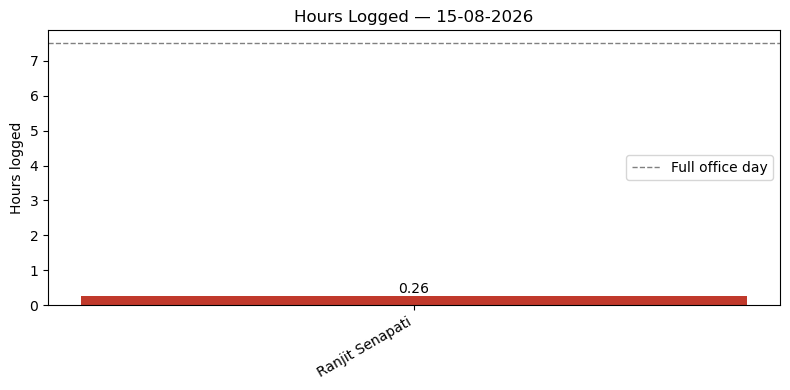

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def show_dashboard(date_str=None):
    """
    date_str: 'DD-MM-YYYY' string, or None for today

    With the tap-in/tap-out model, Status and Day Status are already correct
    at the time each scan happens -- no guessing needed here. This just
    displays and charts what was recorded.
    """
    date_obj = datetime.strptime(date_str, "%d-%m-%Y") if date_str else datetime.now()
    df = load_today_sheet(date_obj)

    if df.empty:
        print(f"No attendance records found for {date_obj.strftime('%d-%m-%Y')}.")
        return

    print(f"Attendance Summary — {date_obj.strftime('%d-%m-%Y')}")
    print(f"Office Hours: {OFFICE_START_TIME} - {OFFICE_END_TIME}")
    print("=" * 55)
    print(f"Total people marked present: {len(df)}")
    print(f"Checked out (full record): {(df['Day Status'] == 'Checked Out').sum()}")
    print(f"Still checked in (no exit scan yet): {(df['Day Status'] == 'Present').sum()}")
    print(f"Late arrivals: {df['Status'].str.contains('Late').sum()}")
    print(f"Early leaves: {df['Status'].str.contains('Early Leave').sum()}")
    print("=" * 55)
    display(df[["ID", "Name", "Date", "Entry Time", "Exit Time", "Total Hours", "Status", "Day Status"]])

    # Only chart people who have actually checked out (have a valid Total Hours)
    checked_out = df[df["Day Status"] == "Checked Out"].copy()
    if checked_out.empty:
        print("\nNo one has checked out yet today — chart will appear once exit scans are logged.")
        return

    def bar_color(status):
        if "Late" in status and "Early Leave" in status:
            return "#c0392b"   # dark red — both late and left early
        elif "Late" in status:
            return "#e67e22"   # orange — late only
        elif "Early Leave" in status:
            return "#f1c40f"   # yellow — early leave only
        return "#2ecc71"       # green — on time, full day

    checked_out["Total Hours"] = checked_out["Total Hours"].astype(float)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(checked_out["Name"], checked_out["Total Hours"],
                   color=[bar_color(s) for s in checked_out["Status"]])
    full_day_hours = (datetime.strptime(OFFICE_END_TIME, "%H:%M") -
                       datetime.strptime(OFFICE_START_TIME, "%H:%M")).seconds / 3600
    ax.axhline(y=full_day_hours, color="gray", linestyle="--", linewidth=1, label="Full office day")
    ax.set_ylabel("Hours logged")
    ax.set_title(f"Hours Logged — {date_obj.strftime('%d-%m-%Y')}")
    ax.bar_label(bars, fmt="%.2f")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Show today's dashboard
show_dashboard()

# To check a specific past date instead, use:
# show_dashboard("28-07-2026")

## Going Further (Optional Improvements)

Ideas to extend this project further:

1. **Higher accuracy recognition** — swap LBPH for the `face_recognition` library (dlib-based, uses
   128-d face embeddings). Same folder structure works; just replace Steps 4 & 6 with dlib's
   `face_encodings()` + `compare_faces()`.
2. **Email/WhatsApp alerts** — notify admin when an "Unknown" face is detected too many times (possible
   intruder), using `smtplib` or a WhatsApp API.
3. **Web dashboard** — wrap Step 7 in a `Streamlit` app for a shareable live dashboard instead of
   viewing it only in Jupyter.
4. **Anti-spoofing** — add a liveness check (e.g., blink detection) so a printed photo can't fool the
   camera.
5. **Multiple camera / IP camera support** — replace `CAMERA_INDEX` with an RTSP URL string for CCTV-based
   attendance.
6. **Database instead of Excel** — for larger organizations, log to SQLite/MySQL and use Excel only as
   an export option (`pandas.read_sql` → `to_excel`).
7. **GUI app** — package Steps 3–7 into a `Tkinter` or `PyQt` desktop app so non-technical staff don't
   need Jupyter to run it.

---

## Quick Recap — How to Use This Notebook

| Step | What to do | When to re-run |
|------|-------------|-----------------|
| 0–2  | Install packages, set up folders, configure settings | Once |
| 3    | Register each person's face | Once per new person |
| 4    | Train the model | After every new registration |
| 5    | Load attendance helper functions | Once per notebook session |
| 6    | Run live attendance recognition | Every day/session |
| 7    | View dashboard | Anytime, to check records |

Your exported Excel files will be in: **`attendance_records/Attendance_<Month>_<Year>.xlsx`**,
with one sheet per date, containing **ID, Name, Date, Entry Time, Exit Time, Total Hours, Status**.
